#### Diplomado - Técnicas Estadísticas y Minería de Datos
#### Módulo II - Modelos Estadísticos
#### Alumno: Sosa Delgadillo Luis Ruben

# Notebook 3: Estadistica inferencial

## Estimadores

Un **estimador** es una regla o una fórmula que, a partir de una muestra $X_1, X_2, \dots, X_n$, produce un valor que usamos para aproximar un parámetro poblacional desconocido $\theta$ (por ejemplo, la media $\mu$ o la varianza $\sigma^2$). Se denota $\hat{\theta}$ o $\hat{\theta}_n$ para dejar explícito que depende del tamaño de muestra $n$, que se propone para aproximar o inferir el valor de un parámetro desconocido de una población.

Es importante diferenciar entre el estimador, que es la función o variable aleatoria genérica $\^{\theta} (X1,…,Xn)$, y la estimación, que es el valor numérico específico que se obtiene al calcular dicha función con los datos particulares $(x_1,\dots,x_n)$ observados en una muestra.

Por ejemplo, la media muestral $\bar{X} = \frac{1}{n}\sum X_i$ es el estimador más común de la media poblacional $\mu$,, y la varianza muestral $(S^2)$ se utiliza para estimar la varianza poblacional $(\sigma^2)$.

*El funcionamiento de un estimador sigue un proceso estadístico estructurado:*

1. **Selección de la muestra aleatoria**: Se recolecta una colección de observaciones o variables aleatorias independientes e idénticamente distribuidas $(X_1, \dots, X_n)$ provenientes de una población cuya distribución de probabilidad depende de un parámetro desconocido.

2. **Aplicación de la estadística**: Se aplica una función que toma los valores de la muestra aleatoria y del tamaño muestral $n$, asegurando que la fórmula utilizada no dependa de ningún parámetro desconocido.

3. **Construcción mediante métodos formales**: Para deducir la fórmula adecuada de un estimador se utilizan métodos analíticos como: 

- Método de momentos: Consiste en igualar los momentos muestrales con los momentos poblacionales teóricos correspondientes y resolver la ecuación resultante para despejar el parámetro.

- Método de máxima verosimilitud: Consiste en encontrar el valor del parámetro que maximiza la función de verosimilitud, es decir, que hace máxima la probabilidad conjunta de haber obtenido la muestra observada.

4. **Evaluación de sus propiedades**: Para medir el rendimiento y confiabilidad del estimador, se analizan propiedades deseables:

- Insesgamiento.
- Consistencia.
- Eficiencia.

### Insesgadez

Un estimador es insesgado si su valor esperado coincide exactamente con el parámetro que quiere estimar:$E(\hat{\theta}) = \theta$

Si $E(\hat{\theta}) \neq \theta$, la diferencia $E(\hat{\theta}) - \theta$ se llama sesgo.

La insesgadez significa que el estimador no se equivoca sistemáticamente hacia un lado, si repitiéramos el proceso de muestreo muchas veces y promediamos todos los valores de $\hat{\theta}$ obtenidos, ese promedio se acercaría exactamente al valor verdadero $\theta$. 

Un estimador insesgado puede fallar mucho en una sola muestra, pero a la larga acierta, no implica que una estimación particular sea buena, sino que no hay una tendencia a sobre- o sub-estimar.

In [ ]:
# Librerías que usaremos a lo largo de todo el notebook
import numpy as np                  # Cálculo numérico y generación de números aleatorios
import matplotlib.pyplot as plt     # Gráficas
from scipy import stats             # Distribuciones de probabilidad

# Configuración estética básica de las gráficas
plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["axes.grid"] = True

In [2]:
# Establecemos los parámetros absolutos de la población
mu_poblacional = 50.0 # Media verdadera
varianza_poblacional = 25.0 # Varianza verdadera (Desviación estándar de 5)

# Generamos una población masiva
# 100,000 individuos, valor promedio de 50, y con una varianza de 25
np.random.seed(42) # semilla para resultados reproducibles 
poblacion = np.random.normal(loc=mu_poblacional, scale=np.sqrt(varianza_poblacional), size=100000)

# Muestreo
tamaño_muestra_n = 10
repeticiones = 5000

# Guardamos los resultados de los 10,000 intentos
estimaciones_medias = np.zeros(repeticiones)
estimaciones_var_sesgada = np.zeros(repeticiones)
estimaciones_var_insesgada = np.zeros(repeticiones)

# Ejecución del expertimento
for i in range(repeticiones):
    # Extraemos una muestra aleatoria de tamaño 10
    muestra = np.random.choice(poblacion, size=tamaño_muestra_n, replace=False)
    
    # Estimador de la media
    estimaciones_medias[i] = np.mean(muestra)
    
    # Estimador de varianza sesgada (divide entre n)
    estimaciones_var_sesgada[i] = np.var(muestra, ddof=0)
    
    # Estimador de varianza insesgada (divide entre n-1)
    estimaciones_var_insesgada[i] = np.var(muestra, ddof=1)


# Calculamos el promedio a largo plazo de nuestros estimadores
E_media = np.mean(estimaciones_medias)
E_var_sesgada = np.mean(estimaciones_var_sesgada)
E_var_insesgada = np.mean(estimaciones_var_insesgada)

In [3]:
# Imprimimos los resultados
print(f"Media poblacional: {mu_poblacional:.3f}")
print(f"Valor esperado E(Media Muestral): {E_media:.3f}")
print("-" * 65)
print(f"Varianza poblacional: {varianza_poblacional:.3f}")
print(f"Valor esperado (varianza sesgada): {E_var_sesgada:.3f}  (subestimación del sistema)")
print(f"Valor esperado (varianza insesgada):{E_var_insesgada:.3f} (insesgo del sistema)")

Media poblacional: 50.000
Valor esperado E(Media Muestral): 49.992
-----------------------------------------------------------------
Varianza poblacional: 25.000
Valor esperado (varianza sesgada): 22.515  (subestimación del sistema)
Valor esperado (varianza insesgada):25.017 (insesgo del sistema)


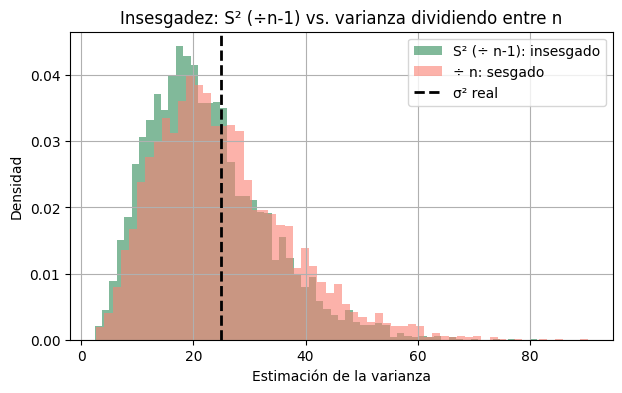

In [4]:
#Gráficamos
plt.hist(estimaciones_var_sesgada, bins=60, alpha=0.6, label="S² (÷ n-1): insesgado", color="seagreen", density=True)
plt.hist(estimaciones_var_insesgada, bins=60, alpha=0.6, label="÷ n: sesgado", color="salmon", density=True)
plt.axvline(varianza_poblacional, color="black", linestyle="--", linewidth=2, label="σ² real")
plt.xlabel("Estimación de la varianza"); plt.ylabel("Densidad")
plt.title("Insesgadez: S² (÷n-1) vs. varianza dividiendo entre n")
plt.legend()
plt.show()

#### Interpretación

A pesar de haber repetido el experimento 5000 veces y promediar todos los resultados, notamos en la varianza sesgada que el número jamás logró acercarse a $25$. Se quedó atascado cerca de $22.5$.

Esto demuestra que el sesgo estadístico no es una  casualidad que se pueda arreglar tomando más muestras, es un defecto estructural en la fórmula, al cambiar el denominador a $n-1$, el estimador recobra su insesgadez geométrica y su centra  con el parámetro de la población.

### Consistencia

Un estimador es consistente para si, a medida que el tamaño de una muestra $n$ crece, $\hat{\theta}_n$ converge en probabilidad a $\theta$:

$\hat{\theta}_n \xrightarrow{P} \theta \quad \text{cuando } n\to\infty$

es decir, para cualquier $\varepsilon>0$, $P(|\hat{\theta}_n - \theta| > \varepsilon) \to 0$ cuando $n\to\infty$.

La consistencia evalúa el comportamiento asintótico de un estimador, nos muestra qué pasa con muestras cada vez más grandes, mientras más datos usemos, más se aprieta la distribución del estimador alrededor del valor verdadero, y la probabilidad de estar lejos de $\theta$ se hace cada vez más pequeña.

Basicamente desmiente la idea de *"mientras más datos, mejor"*: con $n=5$ el estimador puede variar mucho de muestra a muestra, pero con $n=10000$ prácticamente siempre da un valor muy cercano al real, esta idea es, de hecho, la misma que vimos en la Ley de los Grandes Números para la media muestral.

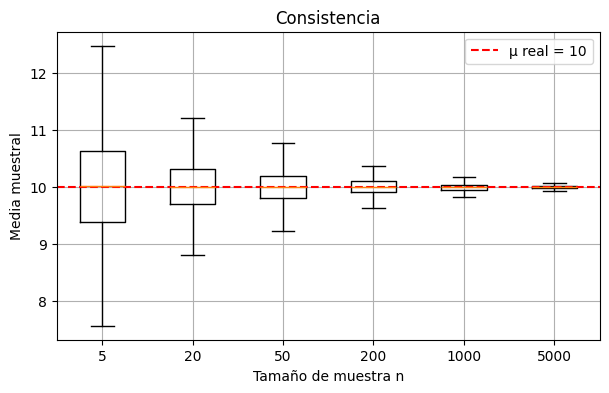

n =     5:  desviación estándar de X̄ = 0.8853
n =    20:  desviación estándar de X̄ = 0.4477
n =    50:  desviación estándar de X̄ = 0.2894
n =   200:  desviación estándar de X̄ = 0.1402
n =  1000:  desviación estándar de X̄ = 0.0641
n =  5000:  desviación estándar de X̄ = 0.0284


In [5]:
mu, sigma = 10, 2
np.random.seed(1)

tamanos = [5, 20, 50, 200, 1000, 5000]
n_reps = 5000

fig, ax = plt.subplots()
data_por_n = []
for n in tamanos:
    muestras = np.random.normal(mu, sigma, size=(n_reps, n))
    medias = muestras.mean(axis=1)
    data_por_n.append(medias)


ax.boxplot(data_por_n, tick_labels=tamanos, showfliers=False)
ax.axhline(mu, color="red", linestyle="--", label=f"μ real = {mu}")
ax.set_xlabel("Tamaño de muestra n")
ax.set_ylabel("Media muestral")
ax.set_title("Consistencia")
ax.legend()
plt.show()

for n, medias in zip(tamanos, data_por_n):
    print(f"n = {n:5d}:  desviación estándar de X̄ = {medias.std():.4f}")


#### Interpretación 

En los diagramas de cajas, cada una representa la distribución de $\bar{X}_n$,  sobre $5000$ muestras repetidas para un tamaño de muestra distinto. 

Las cajas se hacen cada vez más angostas conforme $n$ aumenta, y la tabla confirma que la desviación estándar de $\bar{X}_n$ disminuye con $n$. Esto es la consistencia demostrada con muestras grandes, casi toda la masa de probabilidad de $\bar{X}_n$ queda concentrada muy cerca de $\mu=10$.

### Eficiencia


Entre dos estimadores insesgados de un mismo parámetro $\theta$, se dice que $\hat{\theta}_1$ es más eficiente que $\hat{\theta}_2$ si tiene menor varianza:

$$Var(\hat{\theta}_1) < Var(\hat{\theta}_2)$$

La eficiencia relativa de $\hat{\theta}_2$ respecto a $\hat{\theta}_1$ se define como el cociente: $\frac{Var(\hat{\theta}_1)}{Var(\hat{\theta}_2)}$.

Es decir que si dos estimadores son insesgados, ambos apuntan en promedio al valor correcto, la eficiencia distingue cuál de los dos es más preciso, es decir, cuál produce estimaciones que varían menos de muestra a muestra. 

Un estimador más eficiente "desperdicia" menos información de los datos y da resultados más consistentes entre distintas muestras del mismo tamaño. Por eso, cuando hay que elegir entre varios estimadores insesgados, preferimos el más eficiente, es decir el de menor varianza.

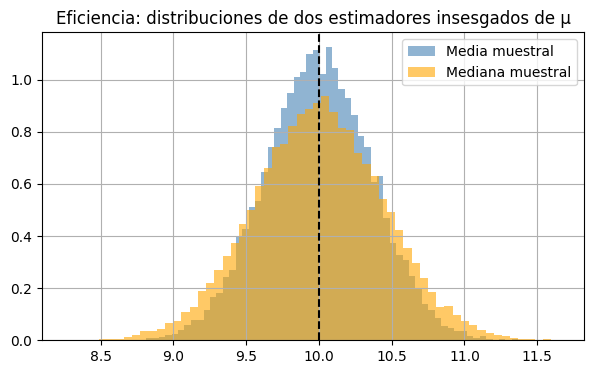

Media muestral E[.] = 9.9989,  Var[.] = 0.1326
Mediana muestral E[.] = 10.0001, Var[.] = 0.1985
Eficiencia relativa = 1.496


In [6]:
mu, sigma = 10, 2
np.random.seed(2)
n = 30
n_reps = 20_000

muestras = np.random.normal(mu, sigma, size=(n_reps, n))
medias   = muestras.mean(axis=1)
medianas = np.median(muestras, axis=1)

fig, ax = plt.subplots()
ax.hist(medias, bins=60, density=True, alpha=0.6, label="Media muestral", color="steelblue")
ax.hist(medianas, bins=60, density=True, alpha=0.6, label="Mediana muestral", color="orange")
ax.axvline(mu, color="black", linestyle="--")
ax.set_title("Eficiencia: distribuciones de dos estimadores insesgados de μ")
ax.legend()
plt.show()

print(f"Media muestral E[.] = {medias.mean():.4f},  Var[.] = {medias.var():.4f}")
print(f"Mediana muestral E[.] = {medianas.mean():.4f}, Var[.] = {medianas.var():.4f}")
print(f"Eficiencia relativa = {medianas.var()/medias.var():.3f}")


#### Interpretación:

Ambos estimadores se centran correctamente en $\mu=10$ es decir que son insesgados, pero el histograma de la mediana muestral es notablemente más disperso que el de la media muestral, y su varianza es mayor, para datos normales, la varianza de la mediana es aproximadamente $\pi/2 \approx 1.57$ veces la de la media.

Esto confirma que, para poblaciones normales, la media muestral es un estimador más eficiente de $\mu$ que la mediana muestral, es decir, ambos aciertan en promedio, pero la media lo hace con menos variabilidad.

### Estimadores básicos

1. Media muestral ($\bar{X}$): Es el promedio aritmético de las observaciones de la muestra, y se usa como estimador puntual directo de la media poblacional $\mu$.

$$\bar{X} = \frac{1}{n}\sum_{i=1}^n X_i$$

2. Varianza muestral ($S^2$) y desviación estándar muestral ($S$):
Miden la dispersión de los datos alrededor de la media muestral, y se usan para estimar la varianza poblacional $\sigma^2$ y la desviación estándar poblacional $\sigma$. Se divide entre $n-1$ (no entre $n$) para que el estimador sea insesgado (ver sección 4.1).

$$S^2 = \frac{1}{n-1}\sum_{i=1}^n (X_i-\bar{X})^2, \qquad S = \sqrt{S^2}$$

3. Error estándar de la media (SEM): Estima cuánto varía $\bar{X}$ de una muestra a otra; es la desviación estándar de la distribución muestral de $\bar{X}$.

$$SEM = \frac{S}{\sqrt{n}}$$

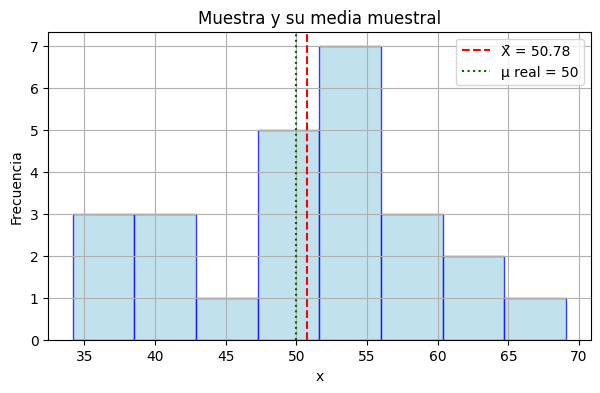

Media muestral (X̄): 50.7770, (μ real = 50)
Varianza muestral (S²): 74.6155, (σ² real = 64)
Desviación estándar muestral (S): 8.6380, (σ real = 8)
Error estándar de la media (SEM): 1.7276


In [7]:
# Ejemplo con una muestra simulada de una población normal(mu=50, sigma=8)
np.random.seed(10)
mu_pob = 50
sigma_pob = 8
n = 25

muestra = np.random.normal(mu_pob, sigma_pob, size=n) # Generamos n observaciones

media_muestral = muestra.mean() # Promedio de la muestra
varianza_muestral = muestra.var(ddof=1) # Divisor n-1
desviacion_muestral = muestra.std(ddof=1) # raíz cuadrada de S^2
sem = desviacion_muestral/np.sqrt(n) # S/sqrt(n)

# Graficamos
plt.hist(muestra, bins=8, color="lightblue", edgecolor="blue", alpha=0.75)
plt.axvline(media_muestral, color="red", linestyle="--", label=f"X̄ = {media_muestral:.2f}")
plt.axvline(mu_pob, color="darkgreen", linestyle=":", label=f"μ real = {mu_pob}")
plt.legend(); plt.title("Muestra y su media muestral")
plt.xlabel("x"); plt.ylabel("Frecuencia")
plt.show()

# Imprimimos resultados
print(f"Media muestral (X̄): {media_muestral:.4f}, (μ real = {mu_pob})")
print(f"Varianza muestral (S²): {varianza_muestral:.4f}, (σ² real = {sigma_pob**2})")
print(f"Desviación estándar muestral (S): {desviacion_muestral:.4f}, (σ real = {sigma_pob})")
print(f"Error estándar de la media (SEM): {sem:.4f}")


#### Interpretación:

La media muestral (línea roja) queda muy cerca de la media poblacional real (línea verde), aunque no exactamente igual, porque proviene de una sola muestra de tamaño finito. 

El SEM cuantifica justamente esa incertidumbre: nos dice qué tan lejos esperaríamos, en promedio, que $\bar{X}$ esté de $\mu$.

### Estimadores por el Método de Momentos

El Método de Momentos consiste en igualar los momentos teóricos de la población, que dependen de los parámetros desconocidos, con los momentos muestrales calculados a partir de los datos, y despejar los parámetros.

Para dos parámetros se usan el primer momento ($E(X)$) y el segundo momento central ($Var(X)$):

$$E(X) = \bar{X}, \qquad Var(X) = \frac{1}{n}\sum_{i=1}^n (X_i-\bar{X})^2 = m_2$$

#### 1. Distribución Gamma ($\alpha,\beta$)

Para $X\sim Gamma(\alpha,\beta)$ sabemos que $E(X)=\alpha/\beta$ y $Var(X)=\alpha/\beta^2$. Igualando a los momentos muestrales:

$$\frac{\alpha}{\beta} = \bar{X}, \qquad \frac{\alpha}{\beta^2} = m_2$$

Dividiendo la primera ecuación entre la segunda se obtiene $\beta$, y sustituyendo se obtiene $\alpha$:

$$\hat{\beta} = \frac{\bar{X}}{m_2}, \qquad \hat{\alpha} = \hat{\beta}\,\bar{X} = \frac{\bar{X}^2}{m_2}$$

Estos son los estimadores correctos que resultan de igualar los dos primeros momentos, es un error común escribir $\hat\alpha$ y $\hat\beta$ como una simple suma de cuadrados esa cantidad, $\sum(X_i-\bar X)^2$, es solo un paso intermedio para calcular $m_2$, no el estimador finall

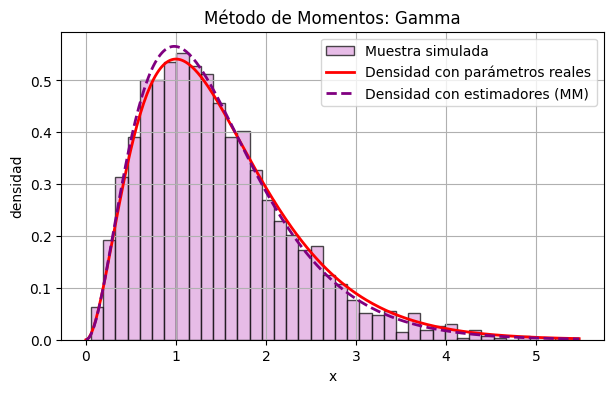

Valores reales: α = 3, β = 2
Estimadores: α_hat = 3.0916, β_hat = 2.1340


In [17]:
from scipy.stats import gamma as gamma_dist

np.random.seed(10)
alpha_real = 3
beta_real = 2
n = 2000

muestra_gamma = np.random.gamma(shape=alpha_real, scale=1/beta_real, size=n)
media_muestral = muestra_gamma.mean() # Promedio de la muestra
varianza_muestral = muestra_gamma.var(ddof=0) # Varianza muestral


beta_hat = media_muestral / varianza_muestral # Estimador de beta
alpha_hat = media_muestral * beta_hat # Estimador de alpha 

#Graficamos
x = np.linspace(0, muestra_gamma.max(), 300)
plt.hist(muestra_gamma, bins=40, density=True, color="plum", edgecolor="black", alpha=0.7, label="Muestra simulada")
plt.plot(x, gamma_dist.pdf(x, a=alpha_real, scale=1/beta_real), color="red", lw=2, label="Densidad con parámetros reales")
plt.plot(x, gamma_dist.pdf(x, a=alpha_hat, scale=1/beta_hat), "--", color="purple", lw=2, label="Densidad con estimadores (MM)")
plt.xlabel("x"); plt.ylabel("densidad")
plt.title("Método de Momentos: Gamma")
plt.legend()
plt.show()

# Imprimimos los resultados
print(f"Valores reales: α = {alpha_real}, β = {beta_real}")
print(f"Estimadores: α_hat = {alpha_hat:.4f}, β_hat = {beta_hat:.4f}")

#### Interpretación:

Los estimadores $\hat{\alpha}$ y $\hat{\beta}$ obtenidos igualando momentos están muy cerca de los valores reales usados para simular los datos, y la curva roja, con los parámetros estimados, prácticamente se superpone con la curva morada, que son los parámetros reales, esto confirma que el método de momentos, aunque es un procedimiento algebraico simple, produce estimaciones razonables.

#### 2. Distribución Exponencial ($\theta$)

Para $X\sim Exp(\theta)$ (con $\theta$ como parámetro de tasa) sabemos que $E(X) = 1/\theta$. Igualando al momento muestral $\bar{X}$:

$$\frac{1}{\theta} = \bar{X} \quad\Rightarrow\quad \hat{\theta} = \frac{1}{\bar{X}}$$

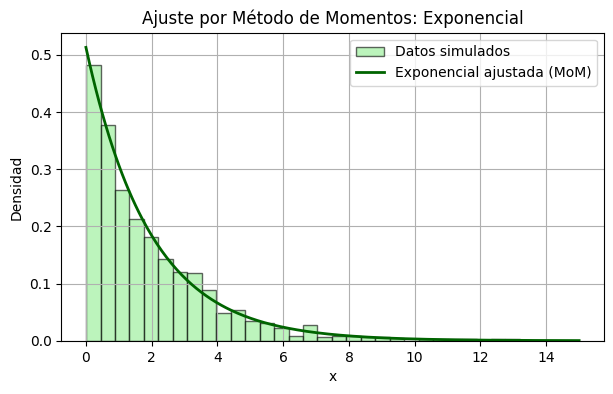

Valor real: θ = 0.5
Estimador: θ_hat= 0.513


In [9]:
# Muestra simulada de una Exponencial
np.random.seed(10)
theta_real = 0.5
n = 1000

muestra = np.random.exponential(scale=1/theta_real, size=n)

theta_hat = 1/muestra.mean()

x = np.linspace(0, 15, 300)
plt.hist(muestra, bins=30, density=True, color="lightgreen", edgecolor="black", alpha=0.6, label="Datos simulados")
plt.plot(x, stats.expon.pdf(x, scale=1/theta_hat), color="darkgreen", lw=2, label="Exponencial ajustada (MoM)")
plt.legend(); plt.title("Ajuste por Método de Momentos: Exponencial")
plt.xlabel("x"); plt.ylabel("Densidad")
plt.show()

print(f"Valor real: θ = {theta_real}")
print(f"Estimador: θ_hat= {theta_hat:.3f}")

#### Interpretación:

El estimador $\hat\theta=1/\bar X$ recupera un valor muy cercano a $\theta=0.5$ a partir de los datos simulados, y la curva ajustada describe bien la forma decreciente del histograma. Como la Exponencial tiene un solo parámetro, el método de momentos se reduce aquí a igualar $\bar X$ con $E(X)=1/\theta$.

### Estimadores por Máxima Verosimilitud (MLE)


El método de máxima verosimilitud busca el valor del parámetro que hace más probable haber observado exactamente los datos de la muestra. Se construye la función de verosimilitud $L(\theta)=\prod_i f(x_i;\theta)$ (o su logaritmo, más fácil de derivar), se deriva respecto al parámetro y se iguala a cero.

#### 1. Distribución Bernoulli / Binomial ($p$)

Para $X_1,\dots,X_n$ Bernoulli($p$) independientes:
$$L(p) = \prod_{i=1}^n p^{X_i}(1-p)^{1-X_i}, \qquad \ell(p) = \left(\sum_i X_i\right)\ln p + \left(n-\sum_i X_i\right)\ln(1-p)$$

Derivando e igualando a cero:
$$\frac{d\ell}{dp} = \frac{\sum_i X_i}{p} - \frac{n-\sum_i X_i}{1-p} = 0 \quad\Longrightarrow\quad \hat{p} = \frac{1}{n}\sum_{i=1}^n X_i = \bar{X}$$

Es decir, el estimador de máxima verosimilitud de $p$ es simplemente la proporción de éxitos observada en la muestra.

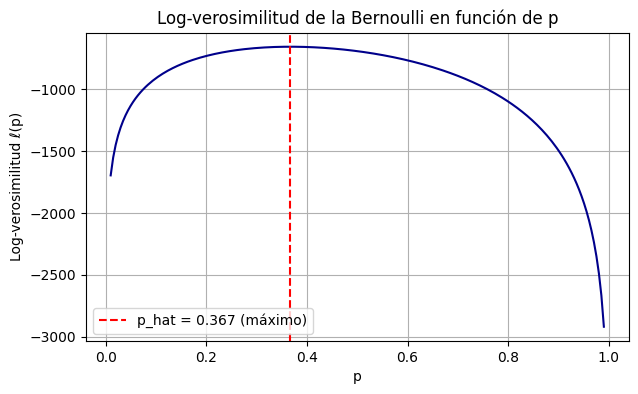

p real = 0.37
p_hat (MLE) = 0.3670


In [10]:
# MLE para Bernoulli/Binomial
# simulamos una muestra de lanzamientos de moneda (p=0.37 de éxito)
np.random.seed(10)
p_real = 0.37
n = 1000

# n ensayos Bernoulli
muestra_bernoulli = np.random.binomial(1, p_real, size=n)

p_hat = muestra_bernoulli.mean() # MLE: proporción de éxitos

suma_exitos = muestra_bernoulli.sum()
p_grid = np.linspace(0.01, 0.99, 200) # Valores posibles de p a evaluar

log_verosimilitud = suma_exitos*np.log(p_grid) + (n-suma_exitos)*np.log(1-p_grid)

# Gráficamos
plt.plot(p_grid, log_verosimilitud, color="darkblue")
plt.axvline(p_hat, color="red", linestyle="--", label=f"p_hat = {p_hat:.3f} (máximo)")
plt.xlabel("p"); plt.ylabel("Log-verosimilitud ℓ(p)")
plt.title("Log-verosimilitud de la Bernoulli en función de p")
plt.legend()
plt.show()

# Imprimimos los reslutados
print(f"p real = {p_real}")
print(f"p_hat (MLE) = {p_hat:.4f}")

#### Interpretación

La curva azul evalúa todos los escenarios posibles (del 1% al 99%), nos muestra qué tan probable es cada valor de $p$ en el eje X, basándose exclusivamente en los datos que recolectaste.

El pico de la curva (Línea roja), es el punto más alto de la montaña responde: "De todo el universo de posibilidades, este valor exacto de $p$ es el que mejor explica los datos que acabamos de observar".

## Intervalos de Confianza

Un estimador puntual (como $\bar X$) da un único número, pero no dice nada sobre qué tan confiable es esa aproximación. Un intervalo de confianza (IC) es un rango de valores, construido a partir de la muestra, que tiene una probabilidad conocida (el nivel de confianza, por ejemplo 95%) de contener al verdadero parámetro poblacional.

La idea es partir de un estimador puntual y sumarle/restarle un margen de error que depende de:

- Qué tan variable es el estimador (su error estándar).
- Qué tan "confiados" queremos estar (el nivel de confianza $1-\alpha$, que fija un valor crítico de la normal o de la t de Student).

$$\text{Intervalo} = \text{estimador puntual} \;\pm\; (\text{valor crítico}) \times (\text{error estándar})$$

Un intervalo de confianza del 95% NO significa que hay 95% de probabilidad de que el parámetro esté dentro de *este* intervalo particular, el parámetro es fijo, no aleatorio. Significa que si repitiéramos el proceso de muestreo muchas veces y construyéramos un intervalo de confianza en cada ocasión, aproximadamente el 95% de esos intervalos contendría al verdadero parámetro.

### 1. IC para la media  con varianza desconocida (muestra pequeña, $n\leq 30$)

Cuando no conocemos $\sigma$ y la muestra es pequeña, usamos la distribución **t de Student** con $n-1$ grados de libertad (más "ancha" que la Normal, para compensar la incertidumbre extra de estimar $\sigma$ con $S$):

$$\bar{X} \;\pm\; t_{\alpha/2,\, n-1}\cdot \frac{S}{\sqrt{n}}$$

In [11]:
# Ejemplo: IC 95% para la media, n=12 (muestra pequeña), sigma desconocida
np.random.seed(10)
datos = np.random.normal(loc=100, scale=15, size=12)

n = len(datos)
media_muestral = datos.mean()
s = datos.std(ddof=1)
confianza = 0.95
alpha = 1 - confianza

t_crit = stats.t.ppf(1 - alpha/2, df=n-1)
margen = t_crit * s/np.sqrt(n)
ic_inf, ic_sup = media_muestral - margen, media_muestral + margen

print(f"n = {n}")
print(f"X̄ = {media_muestral:.2f}, S = {s:.2f}")
print(f"t crítico (gl={n-1}) = {t_crit:.3f}")
print(f"IC {int(confianza*100)}% para μ: ({ic_inf:.2f}, {ic_sup:.2f})")

n = 12
X̄ = 102.79, S = 11.89
t crítico (gl=11) = 2.201
IC 95% para μ: (95.24, 110.35)


#### Interpretación:

Con solo 12 observaciones y $\sigma$ desconocida, usamos la distribución t, más conservadora que la normal para construir el intervalo. Confiamos en que, si repitiéramos este muestreo muchas veces, el 95% de los intervalos calculados de esta forma contendrían la verdadera media poblacional.

### 2. IC para la media $\mu$ con muestra grande ($n>30$)

Cuando la muestra es grande, por el Teorema Central del Límite podemos usar la distribución normal estándar (aunque sigamos usando $S$ como aproximación de $\sigma$, el error de esa aproximación ya es pequeño):

$$\bar{X} \;\pm\; z_{\alpha/2}\cdot \frac{S}{\sqrt{n}}$$


In [12]:
# Ejemplo: IC 95% para la media, n=150 (muestra grande)
np.random.seed(10)
datos = np.random.normal(loc=100, scale=15, size=150)

n = len(datos)
media_muestral = datos.mean()
s = datos.std(ddof=1)
confianza = 0.95
alpha = 1 - confianza

z_crit = stats.norm.ppf(1 - alpha/2)
margen = z_crit * s/np.sqrt(n)
ic_inf, ic_sup = media_muestral - margen, media_muestral + margen

print(f"n = {n}")
print(f"X̄ = {media_muestral:.2f}, S = {s:.2f}")
print(f"z crítico = {z_crit:.3f}")
print(f"IC {int(confianza*100)}% para μ: ({ic_inf:.2f}, {ic_sup:.2f})")

n = 150
X̄ = 101.33, S = 14.77
z crítico = 1.960
IC 95% para μ: (98.97, 103.69)


#### Interpretación:

Con $n=150$ el valor crítico $z=1.96$ es prácticamente igual al de la $t$ correspondiente (que con tantos grados de libertad se parece mucho a la Normal), y el intervalo es notablemente más angosto que en el ejemplo anterior — reflejo directo de tener más información (mayor $n$).

### 3. IC para la varianza $\sigma^2$ de una población Normal

Se construye a partir de los cuantiles de la distribución **Chi-cuadrada** ($\chi^2$) con $n-1$ grados de libertad:

$$\left(\frac{(n-1)S^2}{\chi^2_{\alpha/2,\,n-1}},\; \frac{(n-1)S^2}{\chi^2_{1-\alpha/2,\,n-1}}\right)$$

Hay que notar que el cuantil pequeño ($\chi^2_{\alpha/2}$) va en el denominador del límite superior, y el cuantil grande ($\chi^2_{1-\alpha/2}$) va en el denominador del límite inferior, es decir, la distribución chi-cuadrada no es simétrica.

In [13]:
# Ejemplo: IC 95% para la varianza, n=20
np.random.seed(10)
datos = np.random.normal(loc=50, scale=8, size=20)

n = len(datos)
s2 = datos.var(ddof=1)
confianza = 0.95
alpha = 1 - confianza

chi2_inf = stats.chi2.ppf(alpha/2, df=n-1)       # cuantil inferior (chi2_{alpha/2})
chi2_sup = stats.chi2.ppf(1 - alpha/2, df=n-1)   # cuantil superior (chi2_{1-alpha/2})

ic_inf = (n-1)*s2 / chi2_sup
ic_sup = (n-1)*s2 / chi2_inf

print(f"n = {n}")
print(f"S^2 = {s2:.2f}")
print(f"IC {int(confianza*100)}% para σ^2: ({ic_inf:.2f}, {ic_sup:.2f})")
print(f"IC {int(confianza*100)}% para σ:  ({np.sqrt(ic_inf):.2f}, {np.sqrt(ic_sup):.2f})")


n = 20
S^2 = 47.03
IC 95% para σ^2: (27.20, 100.33)
IC 95% para σ:  (5.22, 10.02)


#### Interpretación:

A diferencia del IC para la media, este intervalo es asimétrico respecto a $S^2$, porque la distribución $\chi^2$ no es simétrica. Confiamos en que el 95% de los intervalos construidos así, a partir de repetidas muestras, contendrían la verdadera varianza poblacional $\sigma^2$.

### 4. IC para la diferencia de medias de dos poblaciones Normales

Para comparar las medias $\mu_1$ y $\mu_2$ de dos poblaciones independientes (con varianzas desconocidas pero supuestas iguales), se usa una varianza combinada $S_p^2$ y la distribución t de Student con $n_1+n_2-2$ grados de libertad:

$$S_p^2 = \frac{(n_1-1)S_1^2 + (n_2-1)S_2^2}{n_1+n_2-2}$$
$$(\bar{X}_1 - \bar{X}_2) \;\pm\; t_{\alpha/2,\,n_1+n_2-2}\cdot S_p\sqrt{\frac{1}{n_1}+\frac{1}{n_2}}$$

In [14]:
# Ejemplo: comparar el rendimiento de dos métodos de enseñanza (calificaciones)
np.random.seed(10)
grupo1 = np.random.normal(loc=78, scale=10, size=20)   # método A
grupo2 = np.random.normal(loc=82, scale=9, size=25)    # método B

n1, n2 = len(grupo1), len(grupo2)
x1, x2 = grupo1.mean(), grupo2.mean()
s1_2, s2_2 = grupo1.var(ddof=1), grupo2.var(ddof=1)

sp2 = ((n1-1)*s1_2 + (n2-1)*s2_2) / (n1+n2-2)
sp = np.sqrt(sp2)

confianza = 0.95
alpha = 1 - confianza
t_crit = stats.t.ppf(1-alpha/2, df=n1+n2-2)

margen = t_crit * sp * np.sqrt(1/n1 + 1/n2)
diferencia = x1 - x2
ic_inf, ic_sup = diferencia - margen, diferencia + margen

print(f"X̄1 = {x1:.2f}, X̄2 = {x2:.2f}")
print(f"diferencia = {diferencia:.2f}")
print(f"IC {int(confianza*100)}% para (μ1 - μ2): ({ic_inf:.2f}, {ic_sup:.2f})")

X̄1 = 79.19, X̄2 = 82.93
diferencia = -3.74
IC 95% para (μ1 - μ2): (-9.20, 1.72)


#### Interpretación:

Como el intervalo obtenido es completamente negativo (no incluye el cero), tenemos evidencia al 95% de confianza de que las medias poblacionales de los dos grupos **sí difieren**, y que el grupo 2 tiende a tener una media mayor. Si el intervalo hubiera incluido el 0, no habría evidencia suficiente para afirmar que las medias son distintas.

### 5. IC para el cociente de dos varianzas poblacionales

Para comparar la variabilidad de dos poblaciones normales independientes, se usa el cociente $S_1^2/S_2^2$ y los cuantiles de la distribución F con $(n_1-1, n_2-1)$ grados de libertad:

$$\left(\frac{S_1^2}{S_2^2}\cdot\frac{1}{F_{\alpha/2,\,n_1-1,\,n_2-1}},\;\; \frac{S_1^2}{S_2^2}\cdot F_{\alpha/2,\,n_2-1,\,n_1-1}\right)$$

In [15]:
# Ejemplo: usamos los mismos dos grupos del ejemplo anterior, para comparar sus varianzas
confianza = 0.95
alpha = 1 - confianza

F_a2_n1n2 = stats.f.ppf(1-alpha/2, dfn=n1-1, dfd=n2-1)   # F_{alpha/2, n1-1, n2-1}
F_a2_n2n1 = stats.f.ppf(1-alpha/2, dfn=n2-1, dfd=n1-1)   # F_{alpha/2, n2-1, n1-1}

cociente = s1_2/s2_2
ic_inf = cociente / F_a2_n1n2
ic_sup = cociente * F_a2_n2n1

print(f"S1² = {s1_2:.2f}, S2² = {s2_2:.2f}, cociente S1²/S2² = {cociente:.3f}")
print(f"IC {int(confianza*100)}% para σ1²/σ2²: ({ic_inf:.3f}, {ic_sup:.3f})")

S1² = 73.49, S2² = 87.76, cociente S1²/S2² = 0.837
IC 95% para σ1²/σ2²: (0.357, 2.053)


#### Interpretación:

Como el intervalo incluye el valor 1, no hay evidencia suficiente para afirmar que las varianzas poblacionales de los dos grupos sean diferentes, es razonable seguir asumiendo varianzas iguales, lo cual justifica, en retrospectiva, haber usado la varianza combinada $S_p^2$.

### 6. IC para una proporción

Para una proporción muestral $\hat p$ (por ejemplo, la fracción de éxitos en $n$ ensayos Bernoulli), y usando la aproximación Normal (válida cuando $n\hat p$ y $n(1-\hat p)$ son razonablemente grandes, por ejemplo $\geq 5$):

$$\hat{p} \pm z_{\alpha/2}\sqrt{\frac{\hat{p}(1-\hat{p})}{n}}$$

In [16]:
# Ejemplo: encuesta a 400 personas, 236 dicen aprobar cierta medida
np.random.seed(24)
n = 400
exitos = 236
p_hat = exitos/n

confianza = 0.95
alpha = 1 - confianza
z_crit = stats.norm.ppf(1-alpha/2)

margen = z_crit * np.sqrt(p_hat*(1-p_hat)/n)
ic_inf, ic_sup = p_hat - margen, p_hat + margen

print(f"p̂ = {p_hat:.4f}  (n={n}, éxitos={exitos})")
print(f"IC {int(confianza*100)}% para p: ({ic_inf:.4f}, {ic_sup:.4f})")

p̂ = 0.5900  (n=400, éxitos=236)
IC 95% para p: (0.5418, 0.6382)


#### Interpretación:

Confiamos en que el verdadero porcentaje poblacional de aprobación está, con 95% de confianza, dentro del intervalo calculado, como todo el intervalo está por encima de 0.5, hay evidencia de que más de la mitad de la población aprueba la medida.


## Conflusión

Queda claro que los estimadores son el puente fundamental entre los datos observados y las realidades que intentamos comprender, actúan como la regla o fórmula matemática que me permite aproximar parámetros poblacionales desconocidos a partir de los datos de una muestra, sin embargo, el gran aprendizaje es que no basta con aplicar una función a los datos.

Para asegurar la rigurosidad y confiabilidad de los análisis, se debe evaluar formalmente sus propiedades, buscamos que el método elegido sea insesgado, consistente y eficiente. Por otro lado, entender los intervalos de confianza cambia por completo la forma de manejar la incertidumbre. Conformarse con un estimador puntual es insuficiente porque no nos dice qué tan exacto es ese número. 

Entendimos que interpretar un intervalo de confianza se construye manejando un margen de error a ese estimador puntual, dependiendo de la variabilidad y del nivel de confianza deseado. La clave de su interpretación radica en entender que el parámetro poblacional no se mueve; más bien, el repetir un proceso de muestreo múltiples veces, un nivel de confianza del 95% garantiza que aproximadamente el 95% de los intervalos que logran construir terminarán conteniendo el verdadero parámetro fijo.

Pensar de esta forma resultará invaluable al momento de comparar rendimientos o evaluar proporciones reales sin dejarse engañar por el azar de una sola muestra.

## Bibliografia

- Rincón, L. (2019). Una introducción a la estadística inferencial (1ª ed.). Ciudad de México: Facultad de Ciencias, Universidad Nacional Autónoma de México.

- Wackerly, D. D., Mendenhall III, W., & Scheaffer, R. L. (2010). Estadística matemática con aplicaciones (7ª ed.). México, D.F.: Cengage Learning.

- Ross, S. M. (2010). A First Course in Probability (8ª ed.). Upper Saddle River, NJ: Pearson Prentice Hall.

- Mood, A. M., Graybill, F. A., & Boes, D. C. (1974). Introduction to the Theory of Statistics (3ª ed.). New York: McGraw-Hill.